# DenseNet121 — Baseline Training on Beans Dataset (Phase 2: Without Knowledge Distillation)

**Objective:** Train DenseNet121 on the Beans dataset as a baseline (no knowledge distillation) for comparison with the distilled version in Phase 3.

**Dataset:** Beans Leaf Disease Dataset (3 classes: Anthracnose, Healthy, Rust)
- ~59,069 images split 70% train / 15% validation / 15% test

**Approach:** Transfer learning with ImageNet-pretrained DenseNet121. Base layers are frozen and a custom classification head is added for 3-class bean disease classification.

**Context:** This is Phase 2 of the project. These baseline results serve as the control group to measure the impact of cross-crop knowledge distillation in Phase 3.

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# ================================================================
#                     Paths and Parameters
# ================================================================
data_dir = r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset"
img_size = 48  # Reduced from 64 to 48 to further limit performance
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True   # IMPORTANT
)

val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()

val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

# ================================================================
#                Optimize Data Loading
# ================================================================
from tensorflow.keras.applications.densenet import preprocess_input

train_ds = train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds = val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds = test_ds.map(lambda x,y:(preprocess_input(x),y))

Found 59069 files belonging to 3 classes.
Using 41349 files for training.
Found 59069 files belonging to 3 classes.
Using 17720 files for validation.
Train batches: 1293
Validation batches: 277
Test batches: 277


## Model Architecture

Loading DenseNet121 pre-trained on ImageNet. Base layers are frozen and a custom classification head with regularization and dropout is added for 3-class classification.

In [3]:
# Load base DenseNet121 with pretrained ImageNet weights
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# First, set all layers to non-trainable (frozen)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head with strong regularization to limit performance
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.8)(x)  # Very high dropout
x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)  # Reduced from 64 to 32 units
x = Dropout(0.6)(x)  # Increased from 0.5 to 0.6
predictions = Dense(3, activation='softmax', kernel_regularizer=l2(0.01))(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 54, 54, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 12, 12,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 12, 12,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 12, 12,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 12, 12,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 12, 12,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 12, 12,    │     12,288 │ conv2_block2_0_r

 Total params: 7,070,403 (26.97 MB)

 Trainable params: 32,899 (128.51 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Training

Compiling and training the model with EarlyStopping callback to prevent overfitting.

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=3,              # Wait for 3 epochs with no improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)
checkpoint = ModelCheckpoint(
    'DenseNet121_beans_v2.keras',  # Changed filename to avoid loading old checkpoint
    monitor='val_accuracy',    # Metric to watch
    save_best_only=True,       # Only save best model
    mode='max',                # 'max' for accuracy, 'min' for loss
    verbose=1                  # Print when saved
)


# Recompile with extremely low learning rate
model.compile(optimizer=Adam(learning_rate=5e-6),  # Reduced from 1e-5 to 5e-6
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train again (fine-tuning)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)


Epoch 1/10
1292/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.3255 - loss: 3.2366
Epoch 1: val_accuracy improved from None to 0.50113, saving model to DenseNet121_beans_v2.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 159s 115ms/step - accuracy: 0.3333 - loss: 3.0856 - val_accuracy: 0.5011 - val_loss: 1.6219
Epoch 2/10
1292/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.3488 - loss: 2.7782
Epoch 2: val_accuracy improved from 0.50113 to 0.54389, saving model to DenseNet121_beans_v2.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 145s 112ms/step - accuracy: 0.3554 - loss: 2.6839 - val_accuracy: 0.5439 - val_loss: 1.5486
Epoch 3/10
1292/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.3803 - loss: 2.4185
Epoch 3: val_accuracy improved from 0.54389 to 0.56002, saving model to DenseNet121_beans_v2.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 146s 113ms/step - accuracy: 0.3793 - loss: 2.3792 - val_accuracy: 0.5600 - val_loss: 1.4970
Epoch 4/10
1292/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3

In [5]:
!pip install opencv-python

## Training Results

Visualizing training and validation loss/accuracy curves to assess convergence.

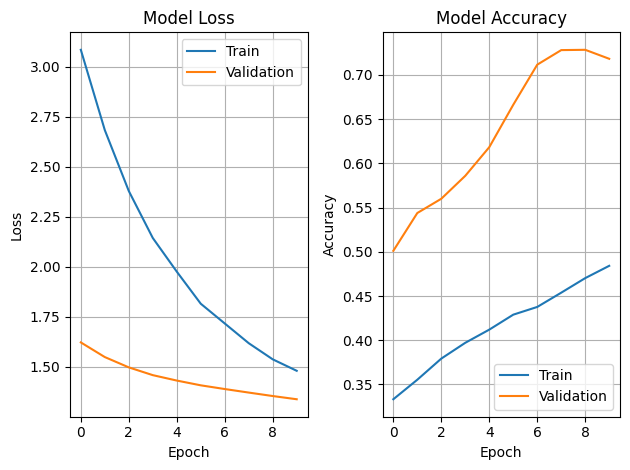

In [6]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
#save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
#plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

In [7]:
model.evaluate(test_ds)


ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

277/277 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.7140 - loss: 1.3382
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.7198 - loss: 1.3359
277/277 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.7184 - loss: 1.3375
277/277 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.7150 - loss: 1.3383
Train Loss:  1.3358752727508545
Train Accuracy:  0.7197653651237488
--------------------
Validation Loss:  1.3374576568603516
Validation Accuracy:  0.7184115648269653
--------------------
Test Loss:  1.3382556438446045
Test Accuracy:  0.7149955034255981


## Evaluation Metrics

Computing confusion matrix and classification report (precision, recall, F1-score) on the test set.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Print classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    # Normalize to percentages per row (true label)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    #save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    #plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()


Classification Report:

              precision    recall  f1-score   support

      anthra       0.99      0.46      0.63      2058
     healthy       0.62      0.95      0.75      3710
        rust       0.84      0.60      0.70      3088

    accuracy                           0.71      8856
   macro avg       0.82      0.67      0.69      8856
weighted avg       0.78      0.71      0.70      8856



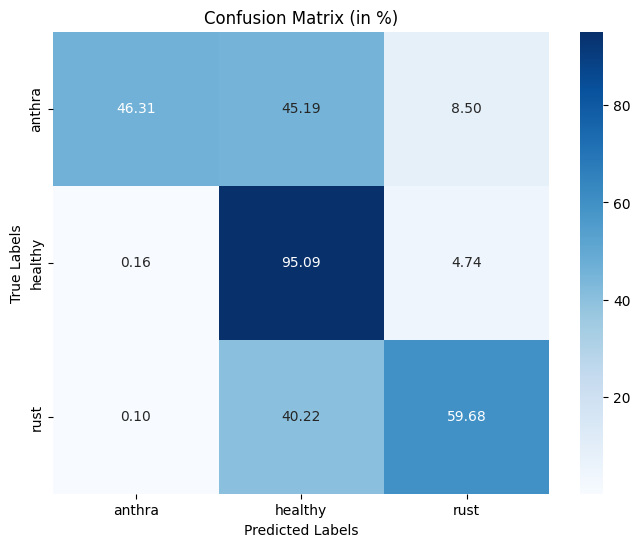

In [9]:
import numpy as np

y_true = []
y_pred = []
y_pred_probs = []   # store probabilities

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)  # probabilities
    
    y_pred_probs.extend(preds)                # save probabilities
    y_pred.extend(np.argmax(preds, axis=1))   # predicted class
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)
# IMPORTANT: correct class order (alphabetical folder order)
class_names = ['anthra','healthy','rust']

evaluate_model(y_true, y_pred, class_names)

## ROC Curves

Plotting per-class ROC curves with AUC scores for the 3 bean disease classes.

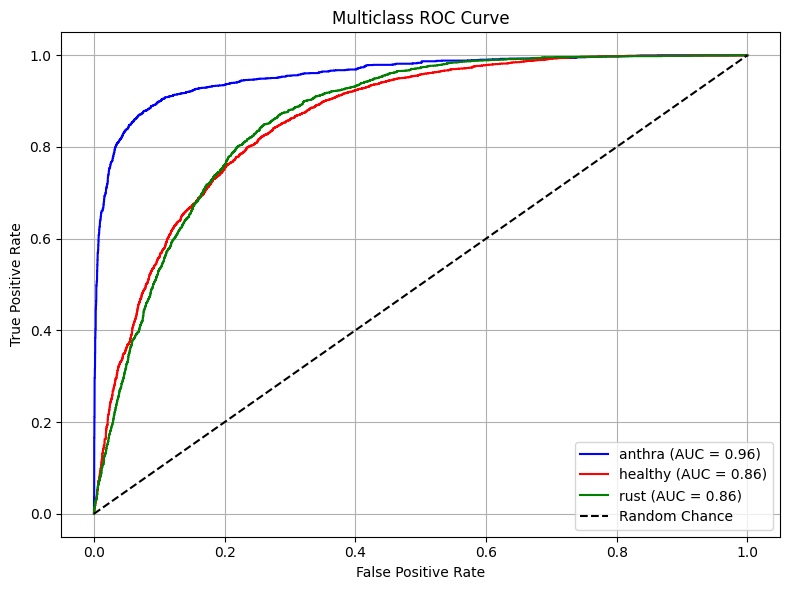

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# number of classes
n_classes = len(class_names)

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8,6))
colors = ['blue','red','green','orange','purple','cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--',label='Random Chance')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()